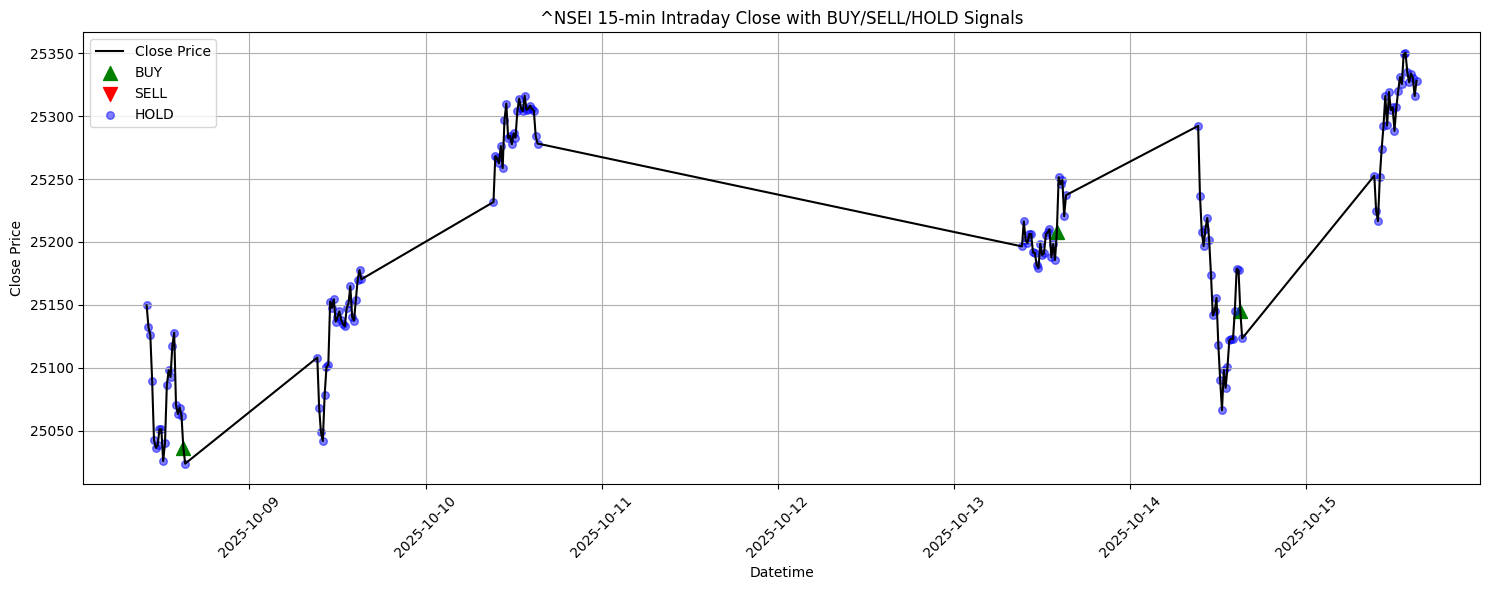

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

# -----------------------------
# 1. Fetch 15-min intraday data
# -----------------------------
ticker = '^NSEI'
period = '30d'  # last 60 days
interval = '15m'

df = yf.Ticker(ticker).history(period=period, interval=interval).reset_index()
df['Datetime'] = pd.to_datetime(df['Datetime']).dt.tz_localize(None)

# -----------------------------
# 2. Feature engineering
# -----------------------------
df['ret1'] = df['Close'].pct_change()
df['ema5'] = df['Close'].ewm(span=5).mean()
df['ema20'] = df['Close'].ewm(span=20).mean()
df['ema_diff'] = df['ema5'] - df['ema20']
df['vol20'] = df['ret1'].rolling(20).std()

# -----------------------------
# 3. Label
# -----------------------------
H = 1  # 1-candle ahead
df['future_ret'] = df['Close'].shift(-H) / df['Close'] - 1
df['y'] = (df['future_ret'] > 0).astype(int)
df.dropna(inplace=True)

# -----------------------------
# 4. Train-test split
# -----------------------------
split = int(len(df)*0.8)
X = df[['ret1','ema_diff','vol20']].values
y = df['y'].values
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# -----------------------------
# 5. Train RandomForest model
# -----------------------------
rf = RandomForestClassifier(n_estimators=200)
clf = CalibratedClassifierCV(rf, method='isotonic', cv=3)
clf.fit(X_train, y_train)

# -----------------------------
# 6. Predict probabilities
# -----------------------------
probs = clf.predict_proba(X_test)[:,1]

# -----------------------------
# 7. Add signals to df_test
# -----------------------------
threshold_buy = 0.6
threshold_sell = 0.4

df_test = df.iloc[split:].copy()
df_test['prob_up'] = probs
df_test['signal'] = df_test['prob_up'].apply(
    lambda p: 'BUY' if p>threshold_buy else ('SELL' if p<threshold_sell else 'HOLD')
)

# -----------------------------
# 8. Plot intraday chart with signals
# -----------------------------
plt.figure(figsize=(15,6))
plt.plot(df_test['Datetime'], df_test['Close'], label='Close Price', color='black')

# BUY signals
buy_signals = df_test[df_test['signal']=='BUY']
plt.scatter(buy_signals['Datetime'], buy_signals['Close'], marker='^', color='green', label='BUY', s=100)

# SELL signals
sell_signals = df_test[df_test['signal']=='SELL']
plt.scatter(sell_signals['Datetime'], sell_signals['Close'], marker='v', color='red', label='SELL', s=100)

# HOLD signals
hold_signals = df_test[df_test['signal']=='HOLD']
plt.scatter(hold_signals['Datetime'], hold_signals['Close'], marker='o', color='blue', label='HOLD', s=30, alpha=0.5)

plt.title(f"{ticker} 15-min Intraday Close with BUY/SELL/HOLD Signals")
plt.xlabel("Datetime")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from plotly.subplots import make_subplots
from datetime import datetime
import time

# -----------------------------
# PARAMETERS
# -----------------------------
ticker = 'NTPC.NS'
interval = '15m'
lookback_days = 7
threshold_buy = 0.6
threshold_sell = 0.4
update_interval = 900  # 15 minutes in seconds

# -----------------------------
# FUNCTION TO FETCH DATA
# -----------------------------
def get_data():
    df = yf.Ticker(ticker).history(period=f"{lookback_days}d", interval=interval).reset_index()
    df['Datetime'] = pd.to_datetime(df['Datetime']).dt.tz_localize(None)
    return df

# -----------------------------
# FUNCTION TO COMPUTE SIGNALS
# -----------------------------
def compute_signals(df):
    df['ret1'] = df['Close'].pct_change()
    df['ema5'] = df['Close'].ewm(span=5).mean()
    df['ema20'] = df['Close'].ewm(span=20).mean()
    df['ema_diff'] = df['ema5'] - df['ema20']
    df['vol20'] = df['ret1'].rolling(20).std()
    
    H = 1
    df['future_ret'] = df['Close'].shift(-H) / df['Close'] - 1
    df['y'] = (df['future_ret'] > 0).astype(int)
    df.dropna(inplace=True)
    
    # Features
    X = df[['ret1','ema_diff','vol20']].values
    y = df['y'].values
    
    # Train model on full data
    rf = RandomForestClassifier(n_estimators=200)
    clf = CalibratedClassifierCV(rf, method='isotonic', cv=3)
    clf.fit(X, y)
    
    df['prob_up'] = clf.predict_proba(X)[:,1]
    df['signal'] = df['prob_up'].apply(lambda p: 'BUY' if p>threshold_buy else ('SELL' if p<threshold_sell else 'HOLD'))
    
    return df

# -----------------------------
# INITIAL DATA
# -----------------------------
df_data = get_data()
df_data = compute_signals(df_data)

# -----------------------------
# FUNCTION TO PLOT INTERACTIVE CHART
# -----------------------------
def plot_signals(df):
    fig = go.Figure()
    
    # Candlestick
    fig.add_trace(go.Candlestick(
        x=df['Datetime'],
        open=df['Open'],
        high=df['High'],
        low=df['Low'],
        close=df['Close'],
        name='OHLC'
    ))
    
    # BUY signals
    buy_signals = df[df['signal']=='BUY']
    fig.add_trace(go.Scatter(
        x=buy_signals['Datetime'],
        y=buy_signals['Close'],
        mode='markers',
        marker=dict(symbol='triangle-up', color='green', size=12),
        name='BUY'
    ))
    
    # SELL signals
    sell_signals = df[df['signal']=='SELL']
    fig.add_trace(go.Scatter(
        x=sell_signals['Datetime'],
        y=sell_signals['Close'],
        mode='markers',
        marker=dict(symbol='triangle-down', color='red', size=12),
        name='SELL'
    ))
    
    # HOLD signals
    hold_signals = df[df['signal']=='HOLD']
    fig.add_trace(go.Scatter(
        x=hold_signals['Datetime'],
        y=hold_signals['Close'],
        mode='markers',
        marker=dict(symbol='circle', color='blue', size=8),
        name='HOLD'
    ))
    
    # Layout
    fig.update_layout(
        title=f'{ticker} 15-min Intraday Chart with BUY/SELL/HOLD Signals (Live)',
        xaxis_title='Datetime',
        yaxis_title='Price',
        xaxis_rangeslider_visible=False,
        template='plotly_dark',
        legend=dict(x=0, y=1.1, orientation='h')
    )
    
    fig.show()

# -----------------------------
# LIVE UPDATING LOOP
# -----------------------------
while True:
    try:
        df_data = get_data()
        df_data = compute_signals(df_data)
        plot_signals(df_data)
        print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] Chart updated")
        time.sleep(update_interval)
    except KeyboardInterrupt:
        print("Live plotting stopped.")
        break
    except Exception as e:
        print("Error:", e)
        time.sleep(update_interval)


[2025-10-15 16:51:31] Chart updated


: 

: 

In [30]:
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from plotly.subplots import make_subplots
from datetime import datetime
import time

# -----------------------------
# PARAMETERS
# -----------------------------
ticker = 'MCX.NS'
interval = '15m'
lookback_days = 60
threshold_buy = 0.6
threshold_sell = 0.4
# update_interval = 900  # 15 minutes in seconds

# -----------------------------
# FUNCTION TO FETCH DATA
# -----------------------------
def get_data():
    df = yf.Ticker(ticker).history(period=f"{lookback_days}d", interval=interval).reset_index()
    df['Datetime'] = pd.to_datetime(df['Datetime']).dt.tz_localize(None)
    return df

# -----------------------------
# FUNCTION TO COMPUTE SIGNALS
# -----------------------------
def compute_signals(df):
    df['ret1'] = df['Close'].pct_change()
    df['ema5'] = df['Close'].ewm(span=5).mean()
    df['ema20'] = df['Close'].ewm(span=20).mean()
    df['ema_diff'] = df['ema5'] - df['ema20']
    df['vol20'] = df['ret1'].rolling(20).std()
    
    H = 1
    df['future_ret'] = df['Close'].shift(-H) / df['Close'] - 1
    df['y'] = (df['future_ret'] > 0).astype(int)
    df.dropna(inplace=True)
    
    # Features
    X = df[['ret1','ema_diff','vol20']].values
    y = df['y'].values
    
    # Train model on full data
    rf = RandomForestClassifier(n_estimators=200)
    clf = CalibratedClassifierCV(rf, method='isotonic', cv=3)
    clf.fit(X, y)
    
    df['prob_up'] = clf.predict_proba(X)[:,1]
    # df['signal'] = df['prob_up'].apply(lambda p: 'BUY' if p>threshold_buy else ('SELL' if p<threshold_sell else 'HOLD'))
    df['signal'] = df['prob_up'].apply(lambda p: 'BUY' if p>threshold_buy else 'SELL')

    
    return df

df_data = get_data()
df_data = compute_signals(df_data)

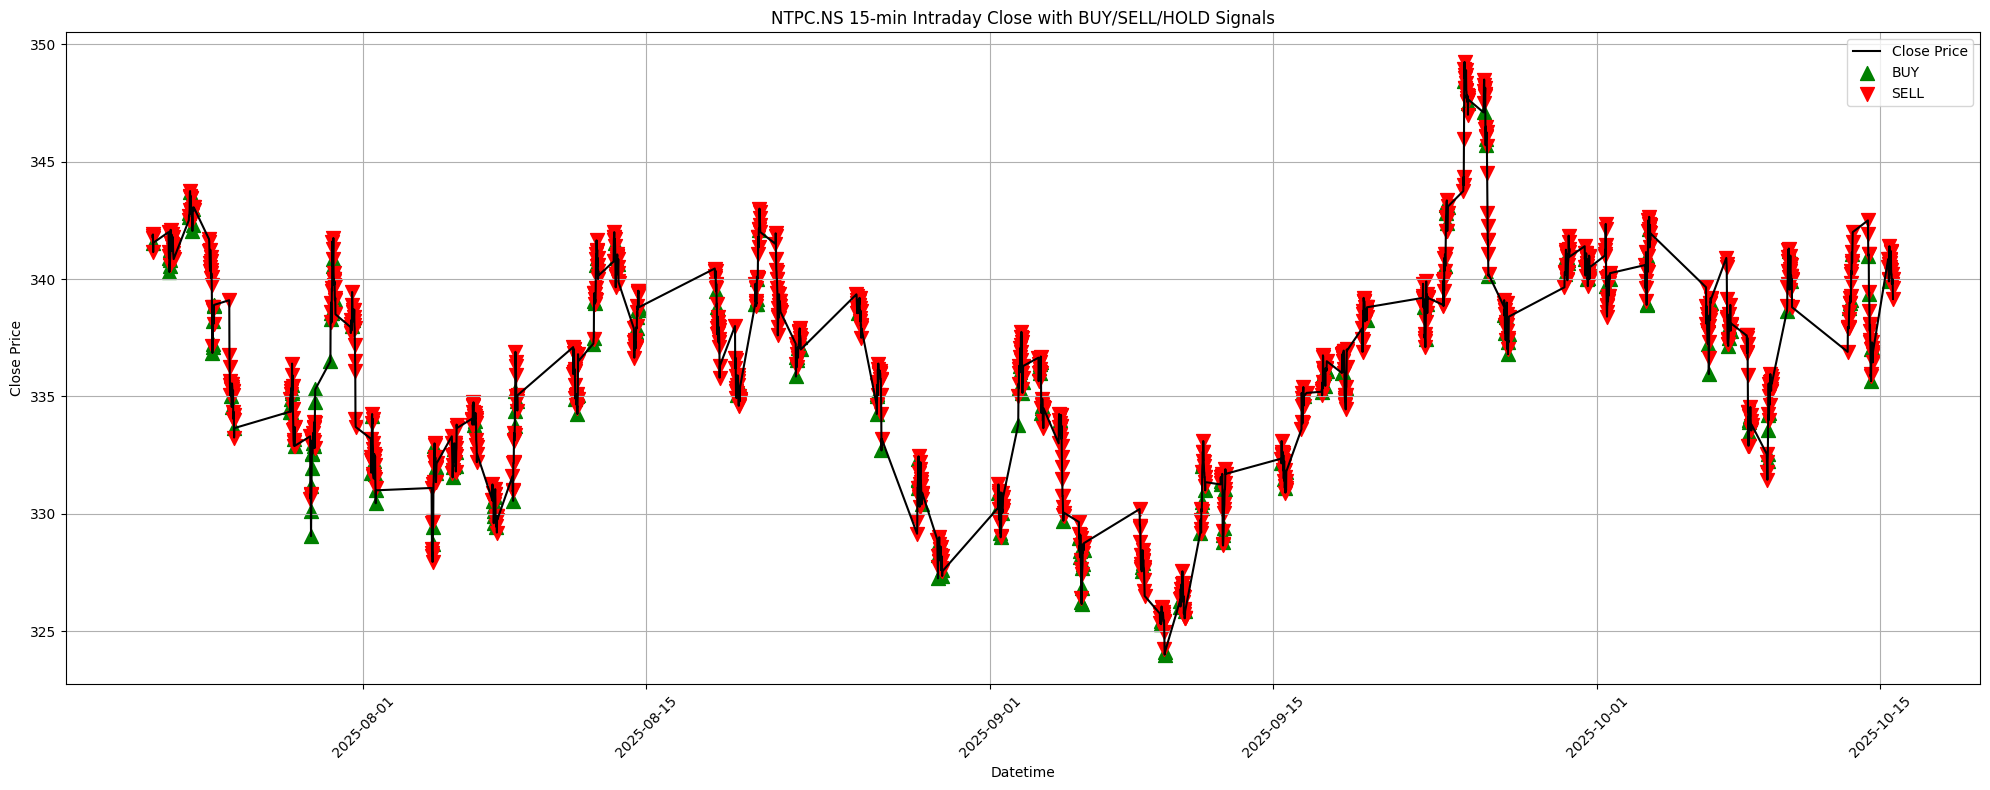

In [20]:
import matplotlib.pyplot as plt

df_test = df_data.copy()
plt.figure(figsize=(20,8))
plt.plot(df_test['Datetime'], df_test['Close'], label='Close Price', color='black')

# BUY signals
buy_signals = df_test[df_test['signal']=='BUY']
plt.scatter(buy_signals['Datetime'], buy_signals['Close'], marker='^', color='green', label='BUY', s=100)

# SELL signals
sell_signals = df_test[df_test['signal']=='SELL']
plt.scatter(sell_signals['Datetime'], sell_signals['Close'], marker='v', color='red', label='SELL', s=100)

# # HOLD signals
# hold_signals = df_test[df_test['signal']=='HOLD']
# plt.scatter(hold_signals['Datetime'], hold_signals['Close'], marker='o', color='blue', label='HOLD', s=30, alpha=0.5)

plt.title(f"{ticker} 15-min Intraday Close with BUY/SELL/HOLD Signals")
plt.xlabel("Datetime")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
df_data[['y','signal']]

,y,signal
20,0,HOLD
21,1,HOLD
22,0,SELL
23,1,HOLD
24,0,HOLD
...,...,...
169,0,SELL
170,1,HOLD
171,0,HOLD
172,0,HOLD


Using lag variables approach

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor

# -----------------------------
# 1. Fetch 15-min intraday data
# -----------------------------
ticker = 'ONGC.NS'
period = '60d'
interval = '15m'

df = yf.Ticker(ticker).history(period=period, interval=interval).reset_index()
df['Datetime'] = pd.to_datetime(df['Datetime']).dt.tz_localize(None)

# -----------------------------
# 2. Feature Engineering
# -----------------------------
df['ret1'] = df['Close'].pct_change()
df['ema5'] = df['Close'].ewm(span=5).mean()
df['ema20'] = df['Close'].ewm(span=20).mean()
df['ema_diff'] = df['ema5'] - df['ema20']
df['vol20'] = df['ret1'].rolling(20).std()
df.dropna(inplace=True)

# -----------------------------
# 3. Model Training (on full data)
# -----------------------------
X = df[['ret1', 'ema_diff', 'vol20']].values
y = df['Close'].values

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X, y)

# -----------------------------
# 4. Prepare last row for forecasting
# -----------------------------
last_row = df.iloc[-1].copy()
future_preds = []

for i in range(4):  # predict next 4 intervals (15-min each)
    X_future = np.array([[last_row['ret1'], last_row['ema_diff'], last_row['vol20']]])
    next_price = model.predict(X_future)[0]
    future_preds.append(next_price)

    # Simulate rolling forward for next iteration
    ret1_new = (next_price / last_row['Close']) - 1
    ema5_new = (last_row['ema5'] * 4 + next_price) / 5
    ema20_new = (last_row['ema20'] * 19 + next_price) / 20
    vol20_new = np.std(df['ret1'].tail(19).tolist() + [ret1_new])

    # Update "last_row" for next iteration
    last_row['Close'] = next_price
    last_row['ret1'] = ret1_new
    last_row['ema5'] = ema5_new
    last_row['ema20'] = ema20_new
    last_row['ema_diff'] = ema5_new - ema20_new
    last_row['vol20'] = vol20_new

# -----------------------------
# 5. Plot only today's prices + predictions
# -----------------------------
today = df['Datetime'].dt.date.max()
df_today = df[df['Datetime'].dt.date == today].copy()

# Future timestamps (next 4 x 15 min)
future_times = pd.date_range(df_today['Datetime'].iloc[-1], periods=5, freq='15min')[1:]

# --- Plotly Interactive Chart ---
fig = go.Figure()

# Today's actual prices
fig.add_trace(go.Scatter(
    x=df_today['Datetime'], y=df_today['Close'],
    mode='lines', name='Today Prices',
    line=dict(color='blue')
))

# Future predictions
fig.add_trace(go.Scatter(
    x=future_times, y=future_preds,
    mode='lines+markers', name='Predicted Next 4 Intervals',
    line=dict(color='red', dash='dot'),
    marker=dict(size=8, symbol='circle')
))

fig.update_layout(
    title=f"{ticker} | Today's 15-min Prices & Next 4×15min Forecast",
    xaxis_title="Time",
    yaxis_title="Price (₹)",
    hovermode='x unified',
    template='plotly_white',
    legend=dict(x=0.01, y=0.99),
    height=600,
    width=950
)

fig.show()


In [36]:
future_preds

[np.float64(154.83459621429444),
 np.float64(138.22500034332276),
 np.float64(147.8471516418457),
 np.float64(148.00440090179444)]

C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_10128\3682237276.py:9: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


Total Trades: 106
Winning Trades: 41
Losing Trades: 65
Total P&L: 2.45%


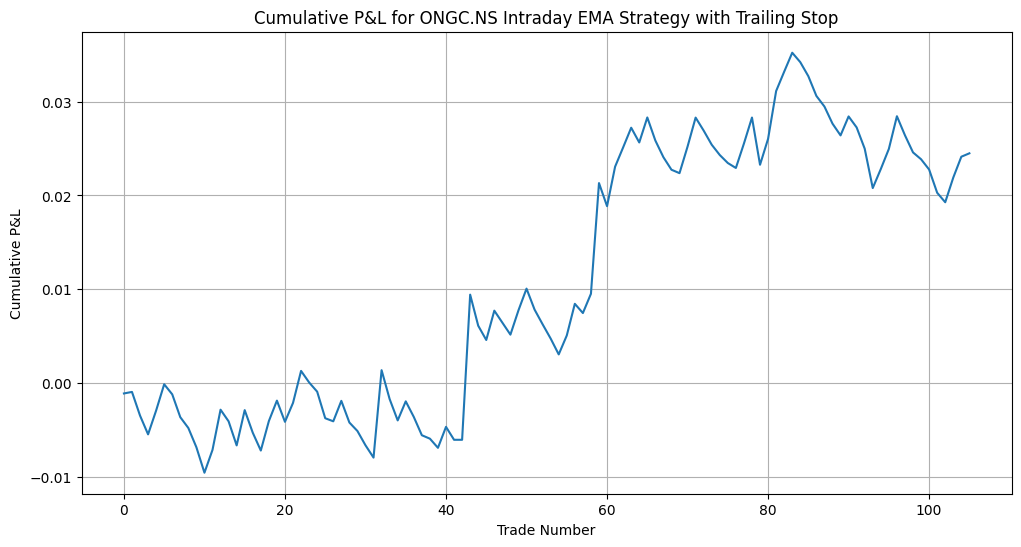

In [14]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1️⃣ Download 5-min intraday data
# ---------------------------
ticker = "ONGC.NS"
df = yf.download(tickers=ticker, period="7d", interval="5m")

# Flatten columns if MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep necessary columns and reset index
df = df[['Open', 'High', 'Low', 'Close']].dropna().reset_index()

# ---------------------------
# 2️⃣ Calculate EMAs
# ---------------------------
df['EMA5'] = df['Close'].ewm(span=5, adjust=False).mean()
df['EMA15'] = df['Close'].ewm(span=15, adjust=False).mean()

# Generate signals
df['Signal'] = 0
df.loc[df['EMA5'] > df['EMA15'], 'Signal'] = 1
df.loc[df['EMA5'] < df['EMA15'], 'Signal'] = -1
df['Signal'] = df['Signal'].astype(int)

# Convert to numpy arrays for scalar operations
signals = df['Signal'].values
closes = df['Close'].values

# ---------------------------
# 3️⃣ Apply Trailing Stop-Loss
# ---------------------------
profit_target = 0.002      # 0.2% fixed profit target
stop_loss = -0.001          # 0.1% fixed stop-loss
trailing_pct = 0.0015       # 0.15% trailing stop

position = 0
entry_price = 0
trail_price = 0
pnl_list = []

for i in range(1, len(df)):
    price = closes[i]
    signal = signals[i-1]
    
    if position == 0:
        if signal == 1:
            position = 1
            entry_price = price
            trail_price = price * (1 - trailing_pct)  # Initial trailing stop
        elif signal == -1:
            position = -1
            entry_price = price
            trail_price = price * (1 + trailing_pct)  # For short positions
    else:
        pnl = (price - entry_price) / entry_price * position
        
        # Update trailing stop
        if position == 1:
            trail_price = max(trail_price, price * (1 - trailing_pct))
        elif position == -1:
            trail_price = min(trail_price, price * (1 + trailing_pct))
        
        # Check exit conditions: profit target, stop loss, trailing stop
        if pnl >= profit_target or pnl <= stop_loss or \
           (position == 1 and price < trail_price) or \
           (position == -1 and price > trail_price):
            pnl_list.append(pnl)
            position = 0
            entry_price = 0
            trail_price = 0

# Close any remaining position
if position != 0:
    pnl_list.append((closes[-1] - entry_price) / entry_price * position)

# ---------------------------
# 4️⃣ Evaluate Performance
# ---------------------------
total_trades = len(pnl_list)
win_trades = sum(1 for x in pnl_list if x > 0)
loss_trades = sum(1 for x in pnl_list if x <= 0)
total_pnl = sum(pnl_list)

print(f"Total Trades: {total_trades}")
print(f"Winning Trades: {win_trades}")
print(f"Losing Trades: {loss_trades}")
print(f"Total P&L: {total_pnl*100:.2f}%")

# ---------------------------
# 5️⃣ Plot Cumulative P&L
# ---------------------------
cumulative_pnl = pd.Series(pnl_list).cumsum()
cumulative_pnl.plot(title=f"Cumulative P&L for {ticker} Intraday EMA Strategy with Trailing Stop", figsize=(12,6))
plt.xlabel("Trade Number")
plt.ylabel("Cumulative P&L")
plt.grid(True)
plt.show()


C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_6320\1094263698.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=ticker, period="7d", interval="5m")
[*********************100%***********************]  1 of 1 completed


Total Trades: 74
Winning Trades: 30
Losing Trades: 44
Total P&L: 1.78%


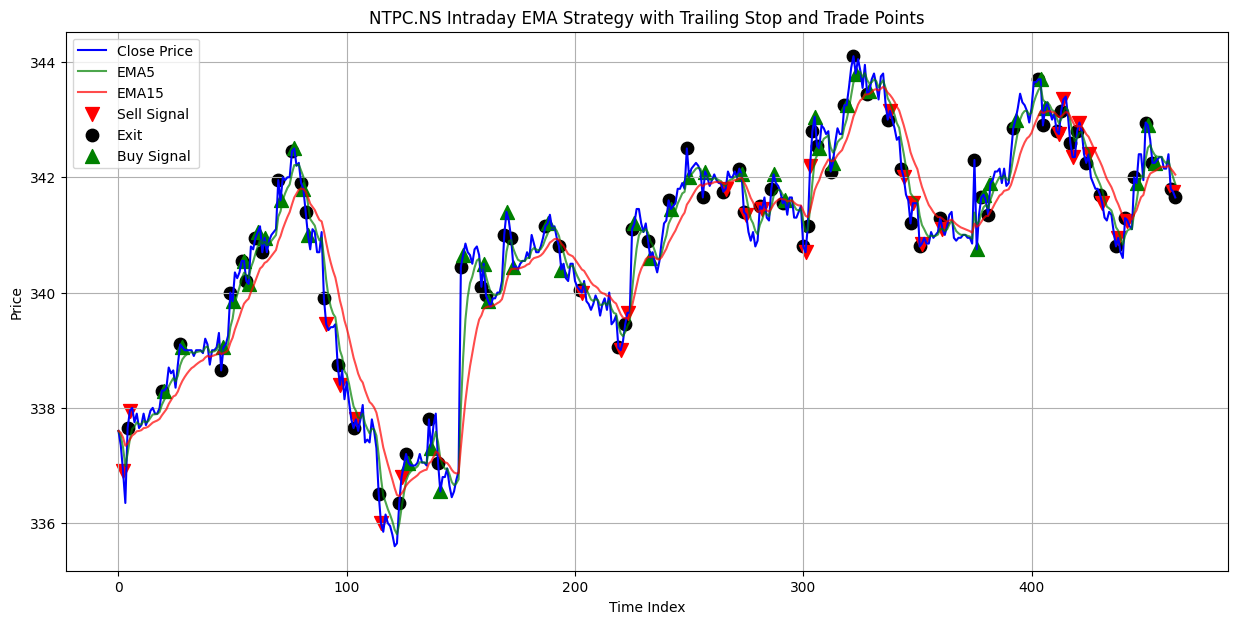

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1️⃣ Download 5-min intraday data
# ---------------------------
ticker = "NTPC.NS"
df = yf.download(tickers=ticker, period="7d", interval="5m")

# Flatten MultiIndex if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[['Open', 'High', 'Low', 'Close']].dropna().reset_index()

# ---------------------------
# 2️⃣ Calculate EMAs
# ---------------------------
df['EMA5'] = df['Close'].ewm(span=5, adjust=False).mean()
df['EMA15'] = df['Close'].ewm(span=15, adjust=False).mean()

# Generate signals
df['Signal'] = 0
df.loc[df['EMA5'] > df['EMA15'], 'Signal'] = 1
df.loc[df['EMA5'] < df['EMA15'], 'Signal'] = -1
df['Signal'] = df['Signal'].astype(int)

# Convert to numpy arrays for scalar operations
signals = df['Signal'].values
closes = df['Close'].values

# ---------------------------
# 3️⃣ Apply Trailing Stop-Loss and track trades
# ---------------------------
profit_target = 0.002      # 0.2% profit
stop_loss = -0.001          # 0.1% loss
trailing_pct = 0.0015       # 0.15% trailing stop

position = 0
entry_price = 0
trail_price = 0
pnl_list = []
trade_points = []  # To store entry/exit info for plotting

for i in range(1, len(df)):
    price = closes[i]
    signal = signals[i-1]
    
    if position == 0:
        if signal == 1:
            position = 1
            entry_price = price
            trail_price = price * (1 - trailing_pct)
            trade_points.append((i, price, 'Buy'))
        elif signal == -1:
            position = -1
            entry_price = price
            trail_price = price * (1 + trailing_pct)
            trade_points.append((i, price, 'Sell'))
    else:
        pnl = (price - entry_price) / entry_price * position
        
        # Update trailing stop
        if position == 1:
            trail_price = max(trail_price, price * (1 - trailing_pct))
        elif position == -1:
            trail_price = min(trail_price, price * (1 + trailing_pct))
        
        # Check exit conditions
        if pnl >= profit_target or pnl <= stop_loss or \
           (position == 1 and price < trail_price) or \
           (position == -1 and price > trail_price):
            pnl_list.append(pnl)
            trade_points.append((i, price, 'Exit'))
            position = 0
            entry_price = 0
            trail_price = 0

# Close any remaining position
if position != 0:
    pnl_list.append((closes[-1] - entry_price) / entry_price * position)
    trade_points.append((len(df)-1, closes[-1], 'Exit'))

# ---------------------------
# 4️⃣ Evaluate Performance
# ---------------------------
total_trades = len(pnl_list)
win_trades = sum(1 for x in pnl_list if x > 0)
loss_trades = sum(1 for x in pnl_list if x <= 0)
total_pnl = sum(pnl_list)

print(f"Total Trades: {total_trades}")
print(f"Winning Trades: {win_trades}")
print(f"Losing Trades: {loss_trades}")
print(f"Total P&L: {total_pnl*100:.2f}%")

# ---------------------------
# 5️⃣ Plot price with trades
# ---------------------------
plt.figure(figsize=(15,7))
plt.plot(df['Close'], label='Close Price', color='blue')
plt.plot(df['EMA5'], label='EMA5', color='green', alpha=0.7)
plt.plot(df['EMA15'], label='EMA15', color='red', alpha=0.7)

# Plot entry and exit points
for idx, price, t_type in trade_points:
    if t_type == 'Buy':
        plt.scatter(idx, price, marker='^', color='green', s=100, label='Buy Signal')
    elif t_type == 'Sell':
        plt.scatter(idx, price, marker='v', color='red', s=100, label='Sell Signal')
    elif t_type == 'Exit':
        plt.scatter(idx, price, marker='o', color='black', s=80, label='Exit')

# Avoid duplicate labels in legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title(f"{ticker} Intraday EMA Strategy with Trailing Stop and Trade Points")
plt.xlabel("Time Index")
plt.ylabel("Price")
plt.grid(True)
plt.show()


C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_6320\2887070612.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=ticker, period="7d", interval="5m")
[*********************100%***********************]  1 of 1 completed


Total Trades: 74
Winning Trades: 30
Losing Trades: 44
Total P&L: 1.78%


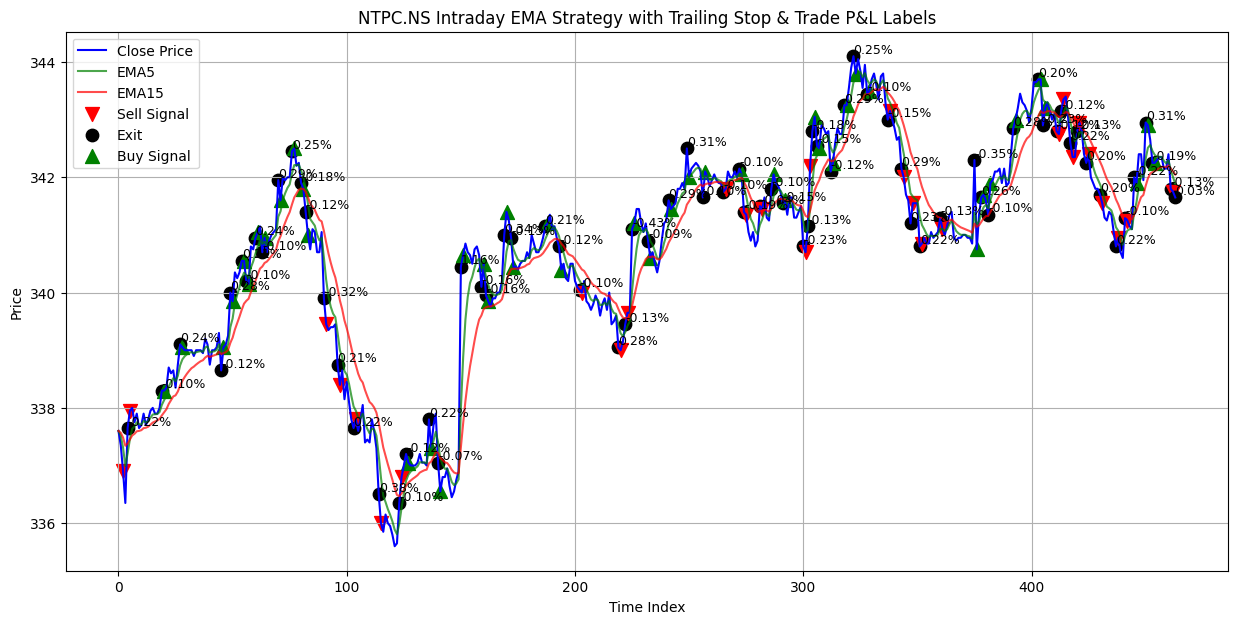

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1️⃣ Download 5-min intraday data
# ---------------------------
ticker = "NTPC.NS"
df = yf.download(tickers=ticker, period="7d", interval="5m")

# Flatten MultiIndex if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[['Open', 'High', 'Low', 'Close']].dropna().reset_index()

# ---------------------------
# 2️⃣ Calculate EMAs
# ---------------------------
df['EMA5'] = df['Close'].ewm(span=5, adjust=False).mean()
df['EMA15'] = df['Close'].ewm(span=15, adjust=False).mean()

# Generate signals
df['Signal'] = 0
df.loc[df['EMA5'] > df['EMA15'], 'Signal'] = 1
df.loc[df['EMA5'] < df['EMA15'], 'Signal'] = -1
df['Signal'] = df['Signal'].astype(int)

# Convert to numpy arrays for scalar operations
signals = df['Signal'].values
closes = df['Close'].values

# ---------------------------
# 3️⃣ Apply Trailing Stop-Loss and track trades
# ---------------------------
profit_target = 0.002      # 0.2% profit
stop_loss = -0.001          # 0.1% loss
trailing_pct = 0.0015       # 0.15% trailing stop

position = 0
entry_price = 0
trail_price = 0
pnl_list = []
trade_points = []  # To store entry/exit info for plotting and labeling

for i in range(1, len(df)):
    price = closes[i]
    signal = signals[i-1]
    
    if position == 0:
        if signal == 1:
            position = 1
            entry_price = price
            trail_price = price * (1 - trailing_pct)
            trade_points.append({'index': i, 'price': price, 'type': 'Buy', 'pnl': None})
        elif signal == -1:
            position = -1
            entry_price = price
            trail_price = price * (1 + trailing_pct)
            trade_points.append({'index': i, 'price': price, 'type': 'Sell', 'pnl': None})
    else:
        pnl = (price - entry_price) / entry_price * position
        
        # Update trailing stop
        if position == 1:
            trail_price = max(trail_price, price * (1 - trailing_pct))
        elif position == -1:
            trail_price = min(trail_price, price * (1 + trailing_pct))
        
        # Check exit conditions
        if pnl >= profit_target or pnl <= stop_loss or \
           (position == 1 and price < trail_price) or \
           (position == -1 and price > trail_price):
            pnl_list.append(pnl)
            trade_points.append({'index': i, 'price': price, 'type': 'Exit', 'pnl': pnl*100})
            position = 0
            entry_price = 0
            trail_price = 0

# Close any remaining position
if position != 0:
    pnl = (closes[-1] - entry_price) / entry_price * position
    pnl_list.append(pnl)
    trade_points.append({'index': len(df)-1, 'price': closes[-1], 'type': 'Exit', 'pnl': pnl*100})

# ---------------------------
# 4️⃣ Evaluate Performance
# ---------------------------
total_trades = len(pnl_list)
win_trades = sum(1 for x in pnl_list if x > 0)
loss_trades = sum(1 for x in pnl_list if x <= 0)
total_pnl = sum(pnl_list)

print(f"Total Trades: {total_trades}")
print(f"Winning Trades: {win_trades}")
print(f"Losing Trades: {loss_trades}")
print(f"Total P&L: {total_pnl*100:.2f}%")

# ---------------------------
# 5️⃣ Plot price with trades and P&L labels
# ---------------------------
plt.figure(figsize=(15,7))
plt.plot(df['Close'], label='Close Price', color='blue')
plt.plot(df['EMA5'], label='EMA5', color='green', alpha=0.7)
plt.plot(df['EMA15'], label='EMA15', color='red', alpha=0.7)

# Plot entry/exit points and annotate P&L
for trade in trade_points:
    idx = trade['index']
    price = trade['price']
    t_type = trade['type']
    pnl = trade['pnl']
    
    if t_type == 'Buy':
        plt.scatter(idx, price, marker='^', color='green', s=100, label='Buy Signal')
    elif t_type == 'Sell':
        plt.scatter(idx, price, marker='v', color='red', s=100, label='Sell Signal')
    elif t_type == 'Exit':
        plt.scatter(idx, price, marker='o', color='black', s=80, label='Exit')
        plt.text(idx, price, f"{pnl:.2f}%", fontsize=9, color='black', ha='left', va='bottom')

# Avoid duplicate labels in legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title(f"{ticker} Intraday EMA Strategy with Trailing Stop & Trade P&L Labels")
plt.xlabel("Time Index")
plt.ylabel("Price")
plt.grid(True)
plt.show()


In [3]:
# pip install yfinance pandas plotly

import yfinance as yf
import pandas as pd
import plotly.graph_objects as go
from time import sleep

ticker = "NTPC.NS"
interval = "5m"  # 5-min candles
ema_fast = 5
ema_slow = 15
profit_target = 0.002
stop_loss = -0.001
trailing_pct = 0.0015

# Function to fetch latest 5-min data
def fetch_data():
    df = yf.download(tickers=ticker, period="7d", interval=interval)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df[['Open', 'High', 'Low', 'Close']].dropna().reset_index()
    df['EMA5'] = df['Close'].ewm(span=ema_fast, adjust=False).mean()
    df['EMA15'] = df['Close'].ewm(span=ema_slow, adjust=False).mean()
    df['Signal'] = 0
    df.loc[df['EMA5'] > df['EMA15'], 'Signal'] = 1
    df.loc[df['EMA5'] < df['EMA15'], 'Signal'] = -1
    df['Signal'] = df['Signal'].astype(int)
    return df

# Initialize trade variables
position = 0
entry_price = 0
trail_price = 0
trade_points = []

# Create initial figure
fig = go.FigureWidget()
fig.add_scatter(name='Close', line=dict(color='blue'))
fig.add_scatter(name='EMA5', line=dict(color='green', dash='dash'))
fig.add_scatter(name='EMA15', line=dict(color='red', dash='dash'))
fig.update_layout(title=f"{ticker} Real-time EMA Strategy",
                  xaxis_title='Time Index', yaxis_title='Price')

fig.show()

# Simulate real-time updates
for _ in range(30):  # simulate 30 updates
    df = fetch_data()
    closes = df['Close'].values
    signals = df['Signal'].values
    
    # Process last candle for trading logic
    i = len(df)-1
    price = closes[i]
    signal = signals[i-1]
    
    global position, entry_price, trail_price
    
    if position == 0:
        if signal == 1:
            position = 1
            entry_price = price
            trail_price = price * (1 - trailing_pct)
            trade_points.append({'index': i, 'price': price, 'type':'Buy', 'pnl':None})
        elif signal == -1:
            position = -1
            entry_price = price
            trail_price = price * (1 + trailing_pct)
            trade_points.append({'index': i, 'price': price, 'type':'Sell', 'pnl':None})
    else:
        pnl = (price - entry_price)/entry_price * position
        if position == 1:
            trail_price = max(trail_price, price*(1-trailing_pct))
        else:
            trail_price = min(trail_price, price*(1+trailing_pct))
        if pnl >= profit_target or pnl <= stop_loss or \
           (position==1 and price<trail_price) or (position==-1 and price>trail_price):
            trade_points.append({'index':i, 'price':price,'type':'Exit','pnl':pnl*100})
            position = 0
            entry_price = 0
            trail_price = 0
    
    # Update chart
    with fig.batch_update():
        fig.data[0].x = df.index
        fig.data[0].y = df['Close']
        fig.data[1].x = df.index
        fig.data[1].y = df['EMA5']
        fig.data[2].x = df.index
        fig.data[2].y = df['EMA15']
        
        # Add trade points markers
        for trace in fig.data[3:]:
            fig.data = fig.data[:3]  # remove old trade points
        for trade in trade_points:
            if trade['type'] == 'Buy':
                fig.add_scatter(x=[trade['index']], y=[trade['price']], mode='markers',
                                marker=dict(symbol='triangle-up', color='green', size=12),
                                name='Buy')
            elif trade['type'] == 'Sell':
                fig.add_scatter(x=[trade['index']], y=[trade['price']], mode='markers',
                                marker=dict(symbol='triangle-down', color='red', size=12),
                                name='Sell')
            elif trade['type'] == 'Exit':
                fig.add_scatter(x=[trade['index']], y=[trade['price']], mode='markers+text',
                                marker=dict(symbol='circle', color='black', size=10),
                                text=[f"{trade['pnl']:.2f}%"], textposition='top center',
                                name='Exit')
    sleep(5)  # wait 5 seconds before fetching new data


C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_6320\1452931387.py:18: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_6320\1452931387.py:18: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_6320\1452931387.py:18: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_6320\1452931387.py:18: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_6320\1452931387.py:18: FutureWarning:

YF.

KeyboardInterrupt: 

In [ ]:
# pip install yfinance pandas dash plotly

import yfinance as yf
import pandas as pd
from dash import Dash, dcc, html
from dash.dependencies import Output, Input
import plotly.graph_objects as go

# ---------------------------
# Parameters
# ---------------------------
ticker = "NTPC.NS"
interval = "5m"
ema_fast = 5
ema_slow = 15
profit_target = 0.002
stop_loss = -0.001
trailing_pct = 0.0015

# Initialize trading variables
position = 0
entry_price = 0
trail_price = 0
trade_points = []

# ---------------------------
# Helper function to fetch data
# ---------------------------
def fetch_data():
    df = yf.download(tickers=ticker, period="7d", interval=interval)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df[['Open','High','Low','Close']].dropna().reset_index()
    df['EMA5'] = df['Close'].ewm(span=ema_fast, adjust=False).mean()
    df['EMA15'] = df['Close'].ewm(span=ema_slow, adjust=False).mean()
    df['Signal'] = 0
    df.loc[df['EMA5'] > df['EMA15'], 'Signal'] = 1
    df.loc[df['EMA5'] < df['EMA15'], 'Signal'] = -1
    df['Signal'] = df['Signal'].astype(int)
    return df

# ---------------------------
# Dash app setup
# ---------------------------
app = Dash(__name__)

app.layout = html.Div([
    html.H1(f"{ticker} Real-Time Intraday EMA Strategy Dashboard"),
    dcc.Graph(id='live-graph'),
    dcc.Interval(
        id='interval-component',
        interval=5*1000,  # Update every 5 seconds
        n_intervals=0
    )
])

# ---------------------------
# Callback to update chart
# ---------------------------
@app.callback(
    Output('live-graph', 'figure'),
    Input('interval-component', 'n_intervals')
)
def update_graph(n):
    global position, entry_price, trail_price, trade_points
    
    df = fetch_data()
    closes = df['Close'].values
    signals = df['Signal'].values
    i = len(df)-1
    price = closes[i]
    signal = signals[i-1]

    # Trading logic
    if position == 0:
        if signal == 1:
            position = 1
            entry_price = price
            trail_price = price * (1 - trailing_pct)
            trade_points.append({'index': i, 'price': price, 'type':'Buy', 'pnl':None})
        elif signal == -1:
            position = -1
            entry_price = price
            trail_price = price * (1 + trailing_pct)
            trade_points.append({'index': i, 'price': price, 'type':'Sell', 'pnl':None})
    else:
        pnl = (price - entry_price)/entry_price * position
        if position == 1:
            trail_price = max(trail_price, price*(1-trailing_pct))
        else:
            trail_price = min(trail_price, price*(1+trailing_pct))
        if pnl >= profit_target or pnl <= stop_loss or \
           (position==1 and price<trail_price) or (position==-1 and price>trail_price):
            trade_points.append({'index':i, 'price':price,'type':'Exit','pnl':pnl*100})
            position = 0
            entry_price = 0
            trail_price = 0
    
    # Plotting
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df.index, y=df['Close'], mode='lines', name='Close Price', line=dict(color='blue')))
    fig.add_trace(go.Scatter(x=df.index, y=df['EMA5'], mode='lines', name='EMA5', line=dict(color='green', dash='dash')))
    fig.add_trace(go.Scatter(x=df.index, y=df['EMA15'], mode='lines', name='EMA15', line=dict(color='red', dash='dash')))

    # Plot trade points with labels
    for trade in trade_points:
        idx = trade['index']
        price = trade['price']
        t_type = trade['type']
        pnl = trade['pnl']
        if t_type == 'Buy':
            fig.add_trace(go.Scatter(x=[idx], y=[price], mode='markers', marker=dict(symbol='triangle-up', color='green', size=12), name='Buy'))
        elif t_type == 'Sell':
            fig.add_trace(go.Scatter(x=[idx], y=[price], mode='markers', marker=dict(symbol='triangle-down', color='red', size=12), name='Sell'))
        elif t_type == 'Exit':
            fig.add_trace(go.Scatter(x=[idx], y=[price], mode='markers+text', marker=dict(symbol='circle', color='black', size=10),
                                     text=[f"{pnl:.2f}%"], textposition='top center', name='Exit'))
    
    fig.update_layout(title=f"{ticker} EMA Strategy Real-Time Chart", xaxis_title="Time Index", yaxis_title="Price", showlegend=True)
    return fig

# ---------------------------
# Run Dash app
# ---------------------------
if __name__ == '__main__':
    app.run(debug=True)


C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_20816\551731306.py:30: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_20816\551731306.py:30: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_20816\551731306.py:30: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_20816\551731306.py:30: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_20816\551731306.py:30: FutureWarning:

YF.

In [ ]:
# pip install yfinance pandas dash plotly

import yfinance as yf
import pandas as pd
from dash import Dash, dcc, html
from dash.dependencies import Output, Input
import plotly.graph_objects as go

# ---------------------------
# Parameters
# ---------------------------
ticker = "COALINDIA.NS"
interval = "5m"
ema_fast = 5
ema_slow = 15
profit_target = 0.002 # 0.2%
stop_loss = -0.001 #0.1%
trailing_pct = 0.0015

# Initialize trading variables
position = 0
entry_price = 0
trail_price = 0
trade_points = []
cumulative_pnl_list = []

# ---------------------------
# Helper function to fetch data
# ---------------------------
def fetch_data():
    df = yf.download(tickers=ticker, period="7d", interval=interval)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df[['Open','High','Low','Close']].dropna().reset_index()
    df['EMA5'] = df['Close'].ewm(span=ema_fast, adjust=False).mean()
    df['EMA15'] = df['Close'].ewm(span=ema_slow, adjust=False).mean()
    df['Signal'] = 0
    df.loc[df['EMA5'] > df['EMA15'], 'Signal'] = 1
    df.loc[df['EMA5'] < df['EMA15'], 'Signal'] = -1
    df['Signal'] = df['Signal'].astype(int)
    return df

# ---------------------------
# Dash app setup
# ---------------------------
app = Dash(__name__)

app.layout = html.Div([
    html.H1(f"{ticker} Real-Time Intraday EMA Strategy Dashboard"),
    html.Div(id='trade-alert', style={'font-size':'20px','color':'red','margin-bottom':'10px'}),
    dcc.Graph(id='live-graph'),
    dcc.Graph(id='cumulative-pnl-graph'),
    dcc.Interval(
        id='interval-component',
        interval=5*1000,  # Update every 5 seconds
        n_intervals=0
    )
])

# ---------------------------
# Callback to update chart and cumulative P&L
# ---------------------------
@app.callback(
    Output('live-graph', 'figure'),
    Output('cumulative-pnl-graph', 'figure'),
    Output('trade-alert', 'children'),
    Input('interval-component', 'n_intervals')
)
def update_dashboard(n):
    global position, entry_price, trail_price, trade_points, cumulative_pnl_list
    
    df = fetch_data()
    closes = df['Close'].values
    signals = df['Signal'].values
    i = len(df)-1
    price = closes[i]
    signal = signals[i-1]

    alert_msg = ""

    # Trading logic
    if position == 0:
        if signal == 1:
            position = 1
            entry_price = price
            trail_price = price * (1 - trailing_pct)
            trade_points.append({'index': i, 'price': price, 'type':'Buy', 'pnl':None})
            alert_msg = f"Buy Signal at {price:.2f}"
        elif signal == -1:
            position = -1
            entry_price = price
            trail_price = price * (1 + trailing_pct)
            trade_points.append({'index': i, 'price': price, 'type':'Sell', 'pnl':None})
            alert_msg = f"Sell Signal at {price:.2f}"
    else:
        pnl = (price - entry_price)/entry_price * position
        if position == 1:
            trail_price = max(trail_price, price*(1-trailing_pct))
        else:
            trail_price = min(trail_price, price*(1+trailing_pct))
        if pnl >= profit_target or pnl <= stop_loss or \
           (position==1 and price<trail_price) or (position==-1 and price>trail_price):
            trade_points.append({'index':i, 'price':price,'type':'Exit','pnl':pnl*100})
            cumulative_pnl_list.append(pnl*100)
            alert_msg = f"Exit Trade at {price:.2f} | P&L: {pnl*100:.2f}%"
            position = 0
            entry_price = 0
            trail_price = 0

    # ---------------------------
    # Plot main price chart with EMA and trade points
    # ---------------------------
    # df.index = df['Datetime']
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df.index, y=df['Close'], mode='lines', name='Close Price', line=dict(color='blue')))
    fig.add_trace(go.Scatter(x=df.index, y=df['EMA5'], mode='lines', name='EMA5', line=dict(color='green', dash='dash')))
    fig.add_trace(go.Scatter(x=df.index, y=df['EMA15'], mode='lines', name='EMA15', line=dict(color='red', dash='dash')))

    for trade in trade_points:
        idx = trade['index']
        price_tp = trade['price']
        t_type = trade['type']
        pnl = trade['pnl']
        if t_type == 'Buy':
            fig.add_trace(go.Scatter(x=[idx], y=[price_tp], mode='markers', marker=dict(symbol='triangle-up', color='green', size=12), name='Buy'))
        elif t_type == 'Sell':
            fig.add_trace(go.Scatter(x=[idx], y=[price_tp], mode='markers', marker=dict(symbol='triangle-down', color='red', size=12), name='Sell'))
        elif t_type == 'Exit':
            fig.add_trace(go.Scatter(x=[idx], y=[price_tp], mode='markers+text', marker=dict(symbol='circle', color='black', size=10),
                                     text=[f"{pnl:.2f}%"], textposition='top center', name='Exit'))

    fig.update_layout(title=f"{ticker} EMA Strategy Real-Time Chart", xaxis_title="Time Index", yaxis_title="Price", showlegend=True)

    # ---------------------------
    # Plot cumulative P&L
    # ---------------------------
    cum_pnl_fig = go.Figure()
    cum_pnl_fig.add_trace(go.Scatter(y=pd.Series(cumulative_pnl_list).cumsum(), mode='lines+markers', name='Cumulative P&L', line=dict(color='purple')))
    cum_pnl_fig.update_layout(title='Cumulative P&L', xaxis_title='Trade Number', yaxis_title='% P&L', showlegend=True)

    return fig, cum_pnl_fig, alert_msg

# ---------------------------
# Run Dash app
# ---------------------------
if __name__ == '__main__':
    app.run(debug=True)


C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_25540\2667064292.py:31: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_25540\2667064292.py:31: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_25540\2667064292.py:31: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_25540\2667064292.py:31: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
C:\Users\ManojKumarNayak\AppData\Local\Temp\ipykernel_25540\2667064292.py:31: FutureWarnin

Links for study and code

In [ ]:
#https://chatgpt.com/share/68f0bc92-ca30-8013-bf37-36bc81d245d4

#https://chatgpt.com/share/68f0bcad-f3fc-8013-9f8f-a759e1cff189

#https://chatgpt.com/share/68f0bccd-7048-8013-9279-ec13fa184fff
#https://chatgpt.com/share/68f0bc92-ca30-8013-bf37-36bc81d245d4

With ngrok


In [6]:
# pip install yfinance pandas dash plotly pyngrok

import yfinance as yf
import pandas as pd
from dash import Dash, dcc, html
from dash.dependencies import Output, Input
import plotly.graph_objects as go
from pyngrok import ngrok

# ---------------------------
# Parameters
# ---------------------------
ticker = "ONGC.NS"
interval = "5m"
ema_fast = 5
ema_slow = 15
profit_target = 0.002
stop_loss = -0.001
trailing_pct = 0.0015

# Initialize trading variables
position = 0
entry_price = 0
trail_price = 0
trade_points = []
cumulative_pnl_list = []

# ---------------------------
# Helper function to fetch data
# ---------------------------
def fetch_data():
    df = yf.download(tickers=ticker, period="7d", interval=interval)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[['Open', 'High', 'Low', 'Close']].dropna().reset_index()
    df['Datetime'] = pd.to_datetime(df['Datetime']).dt.tz_localize(None)
    df['EMA5'] = df['Close'].ewm(span=ema_fast, adjust=False).mean()
    df['EMA15'] = df['Close'].ewm(span=ema_slow, adjust=False).mean()
    df['Signal'] = 0
    df.loc[df['EMA5'] > df['EMA15'], 'Signal'] = 1
    df.loc[df['EMA5'] < df['EMA15'], 'Signal'] = -1
    df['Signal'] = df['Signal'].astype(int)
    return df

# ---------------------------
# Dash app setup
# ---------------------------
app = Dash(__name__)

app.layout = html.Div([
    html.H1(f"{ticker} Real-Time Intraday EMA Strategy Dashboard"),
    html.Div(id='trade-alert', style={'font-size':'20px','color':'red','margin-bottom':'10px'}),
    dcc.Graph(id='live-graph'),
    dcc.Graph(id='cumulative-pnl-graph'),
    dcc.Interval(
        id='interval-component',
        interval=5*1000,  # 5 seconds refresh
        n_intervals=0
    )
])

# ---------------------------
# Callback to update chart and P&L
# ---------------------------
@app.callback(
    Output('live-graph', 'figure'),
    Output('cumulative-pnl-graph', 'figure'),
    Output('trade-alert', 'children'),
    Input('interval-component', 'n_intervals')
)
def update_dashboard(n):
    global position, entry_price, trail_price, trade_points, cumulative_pnl_list

    df = fetch_data()
    closes = df['Close'].values
    signals = df['Signal'].values
    i = len(df) - 1
    price = closes[i]
    signal = signals[i - 1]
    alert_msg = ""

    # ---------------------------
    # Trading logic
    # ---------------------------
    if position == 0:
        if signal == 1:
            position = 1
            entry_price = price
            trail_price = price * (1 - trailing_pct)
            trade_points.append({'datetime': df['Datetime'][i], 'price': price, 'type': 'Buy', 'pnl': None})
            alert_msg = f"Buy Signal at {price:.2f}"
        elif signal == -1:
            position = -1
            entry_price = price
            trail_price = price * (1 + trailing_pct)
            trade_points.append({'datetime': df['Datetime'][i], 'price': price, 'type': 'Sell', 'pnl': None})
            alert_msg = f"Sell Signal at {price:.2f}"
    else:
        pnl = (price - entry_price) / entry_price * position
        if position == 1:
            trail_price = max(trail_price, price * (1 - trailing_pct))
        else:
            trail_price = min(trail_price, price * (1 + trailing_pct))
        if pnl >= profit_target or pnl <= stop_loss or \
           (position == 1 and price < trail_price) or (position == -1 and price > trail_price):
            trade_points.append({'datetime': df['Datetime'][i], 'price': price, 'type': 'Exit', 'pnl': pnl * 100})
            cumulative_pnl_list.append(pnl * 100)
            alert_msg = f"Exit Trade at {price:.2f} | P&L: {pnl * 100:.2f}%"
            position = 0
            entry_price = 0
            trail_price = 0

    # ---------------------------
    # Plot Price & EMA Chart
    # ---------------------------
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df['Datetime'], y=df['Close'], mode='lines', name='Close Price', line=dict(color='blue')))
    fig.add_trace(go.Scatter(x=df['Datetime'], y=df['EMA5'], mode='lines', name='EMA5', line=dict(color='green', dash='dash')))
    fig.add_trace(go.Scatter(x=df['Datetime'], y=df['EMA15'], mode='lines', name='EMA15', line=dict(color='red', dash='dash')))

    for trade in trade_points:
        if trade['type'] == 'Buy':
            fig.add_trace(go.Scatter(x=[trade['datetime']], y=[trade['price']], mode='markers',
                                     marker=dict(symbol='triangle-up', color='green', size=12), name='Buy'))
        elif trade['type'] == 'Sell':
            fig.add_trace(go.Scatter(x=[trade['datetime']], y=[trade['price']], mode='markers',
                                     marker=dict(symbol='triangle-down', color='red', size=12), name='Sell'))
        elif trade['type'] == 'Exit':
            fig.add_trace(go.Scatter(x=[trade['datetime']], y=[trade['price']], mode='markers+text',
                                     marker=dict(symbol='circle', color='black', size=10),
                                     text=[f"{trade['pnl']:.2f}%"], textposition='top center', name='Exit'))

    fig.update_layout(title=f"{ticker} EMA Strategy Real-Time Chart",
                      xaxis_title="Datetime",
                      yaxis_title="Price",
                      showlegend=True)

    # ---------------------------
    # Plot Cumulative P&L Chart
    # ---------------------------
    cum_pnl_fig = go.Figure()
    cum_pnl_fig.add_trace(go.Scatter(
        y=pd.Series(cumulative_pnl_list).cumsum(),
        x=list(range(1, len(cumulative_pnl_list)+1)),
        mode='lines+markers',
        name='Cumulative P&L',
        line=dict(color='purple')
    ))
    cum_pnl_fig.update_layout(title='Cumulative P&L',
                              xaxis_title='Trade Number',
                              yaxis_title='% P&L',
                              showlegend=True)

    return fig, cum_pnl_fig, alert_msg

# ---------------------------
# Run app with ngrok tunnel
# ---------------------------
if __name__ == '__main__':
    port = 8050
    public_url = ngrok.connect(port).public_url
    print(f"\n🎯 Your app is running at: {public_url}\n")
    app.run(host='0.0.0.0', port=port, debug=False)



🎯 Your app is running at: https://kirstie-archoplasmic-tina.ngrok-free.dev



ConnectionError: HTTPConnectionPool(host='0.0.0.0', port=8050): Max retries exceeded with url: /_alive_9de77978-2a28-4b33-b18d-2b656e9e431a (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x000001AE2A6DB460>: Failed to establish a new connection: [WinError 10049] The requested address is not valid in its context'))